In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from xgboost import XGBRegressor
print("All good 🚀")

All good 🚀


In [10]:
model_df = pd.read_csv("../data/processed/bed_occupancy_timeseries.csv")

In [11]:
model_df.duplicated(
    [
        "hospital_id",
        "ward",
        "date"
    ]
).sum()

0

In [12]:
units = (
    model_df[
        [
            "hospital_id",
            "ward"
        ]
    ]
    .drop_duplicates()
)

print("Number of units:", len(units))

units.head()

Number of units: 40


,hospital_id,ward
0,HHN-BIR-01,Cardiology Ward
731,HHN-BIR-01,Day Case Unit
1462,HHN-BIR-01,General Medicine Ward A
2193,HHN-BIR-01,General Medicine Ward B
2924,HHN-BIR-01,Icu


In [17]:
forecast_days = 30

future_results = []
failed_units = []

In [18]:
for index, row in units.iterrows():

    hospital_id = row["hospital_id"]
    ward = row["ward"]

    try:

        # Select one hospital ward
        unit_df = model_df[
            (model_df["hospital_id"] == hospital_id) &
            (model_df["ward"] == ward)
        ].copy()


        # Sort by date
        unit_df = unit_df.sort_values("date")

        # Set date index
        unit_df = unit_df.set_index("date")
        
        unit_df.index = pd.DatetimeIndex(unit_df.index)
        unit_df = unit_df.asfreq("D")

        # Target variable
        y = unit_df["occupied_beds"]


        # Exogenous variables
        exog_features = [
            "daily_admissions",
            "emergency_admissions",
            "daily_ed_arrivals",
            "scheduled_surgeries",
            "planned_staff",
            "actual_staff",
            "staffing_ratio",
            "avg_los_hours",
            "day_of_week",
            "month",
            "quarter",
            "is_weekend",
            "is_holiday"
        ]


        X = unit_df[exog_features].fillna(0)


        # -----------------------------
        # Train SARIMAX using all data
        # -----------------------------

        model = SARIMAX(
            y,
            exog=X,
            order=(1,0,1),
            seasonal_order=(1,0,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )


        model_fit = model.fit(
            disp=False
        )


        # -----------------------------
        # Create future dates
        # -----------------------------

        last_date = unit_df.index.max()


        future_dates = pd.date_range(
            start=last_date + pd.Timedelta(days=1),
            periods=forecast_days,
            freq="D"
        )


        # -----------------------------
        # Create future exogenous data
        # -----------------------------

        future_X = pd.DataFrame(
            index=future_dates
        )


        # Use latest known values
        for col in exog_features:
            future_X[col] = unit_df[col].iloc[-1]


        # Update calendar variables
        future_X["day_of_week"] = future_X.index.dayofweek

        future_X["month"] = future_X.index.month

        future_X["quarter"] = future_X.index.quarter

        future_X["is_weekend"] = (
            future_X["day_of_week"]
            >=5
        ).astype(int)


        # Keep holiday assumption
        future_X["is_holiday"] = 0



        # -----------------------------
        # Generate forecast
        # -----------------------------

        forecast = model_fit.forecast(
            steps=forecast_days,
            exog=future_X
        )


        # -----------------------------
        # Save results
        # -----------------------------

        for date, prediction in zip(
            future_dates,
            forecast
        ):

            future_results.append(
                {
                    "hospital_id": hospital_id,
                    "ward": ward,
                    "date": date,
                    "forecast_occupied_beds": round(prediction,2)
                }
            )


    except Exception as e:


        failed_units.append(
            {
                "hospital_id": hospital_id,
                "ward": ward,
                "error": str(e)
            }
        )

c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Abdiel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

In [28]:
import joblib

In [29]:
joblib.dump(
    model_fit,
    "../models/sarimax/sarimax_futureforecast_7_30d.pkl"
)

['../models/sarimax/sarimax_futureforecast_7_30d.pkl']

In [100]:
sarimax_future_forecast_df.to_csv(
"../data/processed/sarimax_future_forecast.csv",
index=False
)

In [22]:
# Convert results to dataframe

future_forecast_df = pd.DataFrame(future_results)

failed_units_df = pd.DataFrame(failed_units)


# Total number of units tested

total_models = len(units)


# Successful models

successful_models = (
    future_forecast_df[
        ["hospital_id","ward"]
    ]
    .drop_duplicates()
    .shape[0]
)


# Failed models

if len(failed_units_df) > 0:

    failed_models = (
        failed_units_df[
            ["hospital_id","ward"]
        ]
        .drop_duplicates()
        .shape[0]
    )

else:

    failed_models = 0



print("Total SARIMAX models:", total_models)
print("Successful models:", successful_models)
print("Failed models:", failed_models)

Total SARIMAX models: 40
Successful models: 40
Failed models: 0


In [24]:
future_forecast_df.head()

,hospital_id,ward,date,forecast_occupied_beds
0,HHN-BIR-01,Cardiology Ward,2026-01-01,16.26
1,HHN-BIR-01,Cardiology Ward,2026-01-02,18.12
2,HHN-BIR-01,Cardiology Ward,2026-01-03,18.37
3,HHN-BIR-01,Cardiology Ward,2026-01-04,16.55
4,HHN-BIR-01,Cardiology Ward,2026-01-05,16.58


In [25]:
hospital = "HHN-BIR-01"
ward = "Cardiology Ward"


forecast_plot_df = future_forecast_df[
    (future_forecast_df["hospital_id"] == hospital) &
    (future_forecast_df["ward"] == ward)
].copy()


actual_plot_df = model_df[
    (model_df["hospital_id"] == hospital) &
    (model_df["ward"] == ward)
].copy()

##### Sort Date

In [26]:
forecast_plot_df["date"] = pd.to_datetime(
    forecast_plot_df["date"]
)

actual_plot_df["date"] = pd.to_datetime(
    actual_plot_df["date"]
)


forecast_plot_df = forecast_plot_df.sort_values("date")

actual_plot_df = actual_plot_df.sort_values("date")

##### Visualize SARIMAX Future forecast

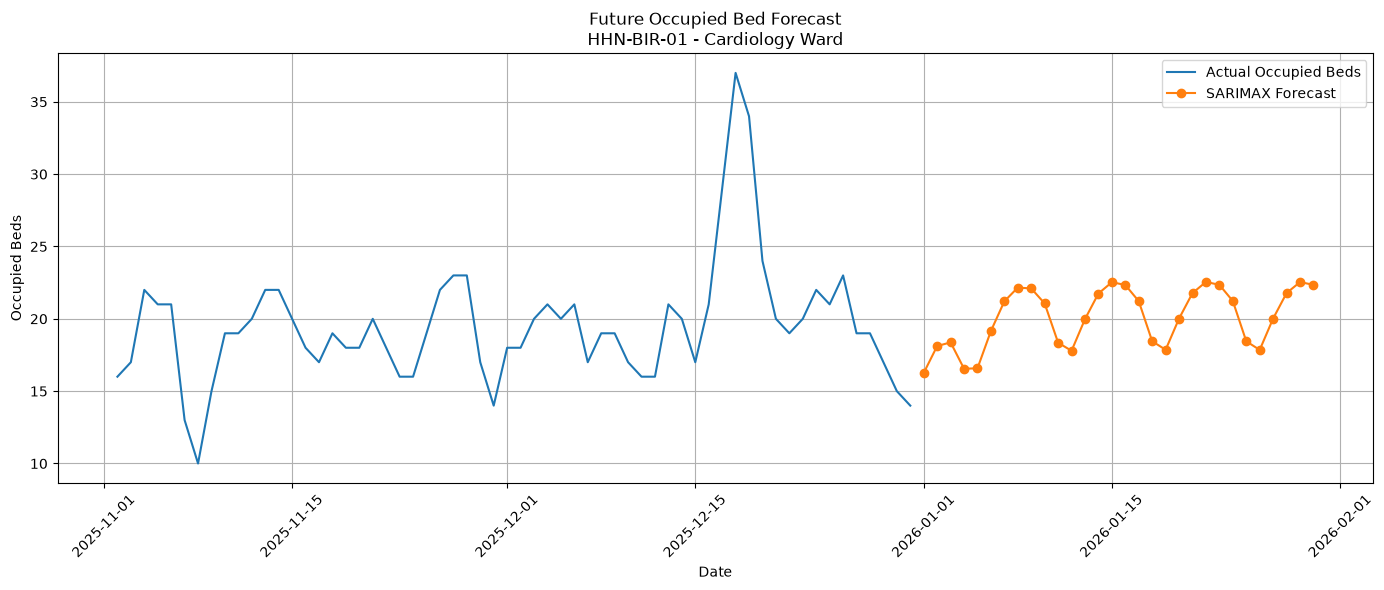

In [27]:
import matplotlib.pyplot as plt


plt.figure(figsize=(14,6))


# Last 60 days actual occupancy
plt.plot(
    actual_plot_df["date"].tail(60),
    actual_plot_df["occupied_beds"].tail(60),
    label="Actual Occupied Beds"
)


# Future forecast
plt.plot(
    forecast_plot_df["date"],
    forecast_plot_df["forecast_occupied_beds"],
    marker="o",
    label="SARIMAX Forecast"
)


plt.title(
    f"Future Occupied Bed Forecast\n{hospital} - {ward}"
)


plt.xlabel("Date")

plt.ylabel("Occupied Beds")


plt.legend()

plt.xticks(rotation=45)

plt.grid(True)


plt.tight_layout()

plt.show()

In [31]:
import warnings

warnings.filterwarnings("ignore")

In [46]:
model_df["date"] = pd.to_datetime(
    model_df["date"]
)

In [47]:
unit_df = model_df[
    (model_df["hospital_id"]=="HHN-BIR-01") &
    (model_df["ward"]=="Cardiology Ward")
]

In [50]:
failed_units_xgb_future = []

xgb_future_results = []


# Loop through every hospital ward

for index, row in units.iterrows():

    hospital_id = row["hospital_id"]
    ward = row["ward"]


    try:

        print(
            f"Forecasting {hospital_id} - {ward}"
        )


        # =========================================
        # 1. Select hospital ward
        # =========================================

        unit_df = model_df[
            (model_df["hospital_id"] == hospital_id) &
            (model_df["ward"] == ward)
        ].copy()


        unit_df["date"] = pd.to_datetime(
            unit_df["date"]
        )


        unit_df = (
            unit_df
            .sort_values("date")
            .reset_index(drop=True)
        )


        # =========================================
        # 2. Train XGBoost model
        # =========================================


        X_train = (
            unit_df[xgb_features]
            .fillna(0)
        )


        y_train = unit_df[
            "occupied_beds"
        ]


        model = XGBRegressor(

            n_estimators=300,

            learning_rate=0.05,

            max_depth=5,

            random_state=42,

            objective="reg:squarederror"

        )


        model.fit(
            X_train,
            y_train
        )


        # =========================================
        # 3. Prepare recursive forecasting
        # =========================================


        history = unit_df.copy()


        future_dates = pd.date_range(

            start=history["date"].max()
            + pd.Timedelta(days=1),

            periods=30,

            freq="D"

        )


        predictions = []


        # =========================================
        # 4. Forecast each future day
        # =========================================


        for future_date in future_dates:


            future_row = {}


            future_row["date"] = future_date



            # =====================================
            # A. Create lag features
            # =====================================


            future_row["lag_1_occupied_beds"] = (

                history["occupied_beds"]
                .iloc[-1]

            )


            future_row["lag_7_occupied_beds"] = (

                history["occupied_beds"]
                .iloc[-7]

            )


            future_row["rolling_7_day_avg"] = (

                history["occupied_beds"]
                .tail(7)
                .mean()

            )


            future_row["rolling_7_day_std"] = (

                history["occupied_beds"]
                .tail(7)
                .std()

            )



            # =====================================
            # B. Create operational features
            # =====================================


            operational_features = [

                "daily_admissions",

                "daily_discharges",

                "emergency_admissions",

                "daily_ed_arrivals",

                "scheduled_surgeries",

                "total_beds",

                "staffed_beds",

                "closed_beds",

                "avg_los_hours",

                "planned_staff",

                "actual_staff",

                "staffing_ratio"

            ]


            for col in operational_features:


                future_row[col] = (

                    history[col]
                    .tail(7)
                    .mean()

                )



            # =====================================
            # C. Create calendar features
            # =====================================


            future_row["day_of_week"] = (

                future_date.dayofweek

            )


            future_row["month"] = (

                future_date.month

            )


            future_row["quarter"] = (

                future_date.quarter

            )


            future_row["is_weekend"] = (

                int(future_date.dayofweek >= 5)

            )


            # Replace with NHS holiday calendar later

            future_row["is_holiday"] = 0



            # =====================================
            # D. Create derived features
            # =====================================


            future_row["admission_pressure"] = (

                future_row["daily_admissions"]

                /

                (
                    future_row["staffed_beds"]
                    + 1e-8
                )

            )


            future_row["staff_shortage"] = (

                future_row["planned_staff"]

                -

                future_row["actual_staff"]

            )


            future_row["emergency_ratio"] = (

                future_row["emergency_admissions"]

                /

                (
                    future_row["daily_admissions"]
                    + 1e-8
                )

            )


            future_row["surgery_per_staff"] = (

                future_row["scheduled_surgeries"]

                /

                (
                    future_row["planned_staff"]
                    + 1e-8
                )

            )



            # =====================================
            # 5. Convert to model input
            # =====================================


            X_future = pd.DataFrame(
                [future_row]
            )


            X_future = (

                X_future[xgb_features]
                .fillna(0)

            )



            # =====================================
            # 6. Predict occupancy
            # =====================================


            prediction = model.predict(
                X_future
            )[0]



            predictions.append({

                "hospital_id": hospital_id,

                "ward": ward,

                "date": future_date,

                "predicted_occupied_beds": round(
                    prediction,
                    2
                )

            })



            # =====================================
            # 7. Update history
            # =====================================
            # Prediction becomes future history

            new_row = history.iloc[-1].copy()


            new_row["date"] = future_date


            new_row["occupied_beds"] = prediction


            history = pd.concat(

                [
                    history,
                    pd.DataFrame([new_row])
                ],

                ignore_index=True

            )



        # Save completed ward forecast

        xgb_future_results.extend(
            predictions
        )


    except Exception as e:


        failed_units_xgb_future.append({

            "hospital_id": hospital_id,

            "ward": ward,

            "error": str(e)

        })



# Convert results

xgb_future_forecast_df = pd.DataFrame(
    xgb_future_results
)


failed_units_xgb_future_df = pd.DataFrame(
    failed_units_xgb_future
)

Forecasting HHN-BIR-01 - Cardiology Ward
Forecasting HHN-BIR-01 - Day Case Unit
Forecasting HHN-BIR-01 - General Medicine Ward A
Forecasting HHN-BIR-01 - General Medicine Ward B
Forecasting HHN-BIR-01 - Icu
Forecasting HHN-BIR-01 - Oncology Ward
Forecasting HHN-BIR-01 - Orthopaedics Ward A
Forecasting HHN-BIR-01 - Orthopaedics Ward B
Forecasting HHN-EDI-01 - Cardiology Ward
Forecasting HHN-EDI-01 - Day Case Unit
Forecasting HHN-EDI-01 - General Medicine Ward A
Forecasting HHN-EDI-01 - General Medicine Ward B
Forecasting HHN-EDI-01 - Icu
Forecasting HHN-EDI-01 - Oncology Ward
Forecasting HHN-EDI-01 - Orthopaedics Ward A
Forecasting HHN-EDI-01 - Orthopaedics Ward B
Forecasting HHN-LON-01 - Cardiology Ward
Forecasting HHN-LON-01 - Day Case Unit
Forecasting HHN-LON-01 - General Medicine Ward A
Forecasting HHN-LON-01 - General Medicine Ward B
Forecasting HHN-LON-01 - Icu
Forecasting HHN-LON-01 - Oncology Ward
Forecasting HHN-LON-01 - Orthopaedics Ward A
Forecasting HHN-LON-01 - Orthopaedics

In [99]:
joblib.dump(
    model_fit,
    "../models/xgboost/xgboost_futureforecast_7_30d.pkl"
)

['../models/xgboost/xgboost_futureforecast_7_30d.pkl']

In [101]:
xgb_future_forecast_df.to_csv(
"../data/processed/xgb_future_forecast.csv",
index=False
)

In [51]:
print(
    "Successful forecasts:",
    len(xgb_future_results)
)

print(
    "Failed units:",
    len(failed_units_xgb_future)
)

Successful forecasts: 1200
Failed units: 0


In [52]:
xgb_future_forecast_df.head(10)

,hospital_id,ward,date,predicted_occupied_beds
0,HHN-BIR-01,Cardiology Ward,2026-01-01,14.98
1,HHN-BIR-01,Cardiology Ward,2026-01-02,14.38
2,HHN-BIR-01,Cardiology Ward,2026-01-03,14.53
3,HHN-BIR-01,Cardiology Ward,2026-01-04,13.69
4,HHN-BIR-01,Cardiology Ward,2026-01-05,12.76
5,HHN-BIR-01,Cardiology Ward,2026-01-06,12.95
6,HHN-BIR-01,Cardiology Ward,2026-01-07,12.63
7,HHN-BIR-01,Cardiology Ward,2026-01-08,12.41
8,HHN-BIR-01,Cardiology Ward,2026-01-09,12.29
9,HHN-BIR-01,Cardiology Ward,2026-01-10,12.30


In [53]:
xgb_future_forecast_df = pd.DataFrame(
    xgb_future_results
)

In [54]:
xgb_future_forecast_df["date"] = pd.to_datetime(
    xgb_future_forecast_df["date"]
)


xgb_future_forecast_df = (
    xgb_future_forecast_df
    .sort_values(
        [
            "hospital_id",
            "ward",
            "date"
        ]
    )
    .reset_index(drop=True)
)

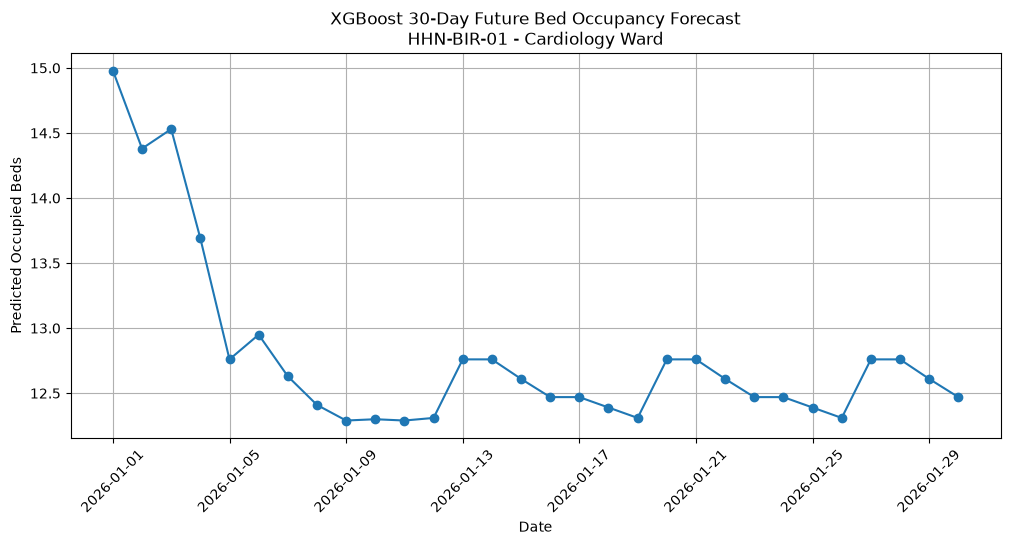

In [55]:
forecast_plot = xgb_future_forecast_df[
    (xgb_future_forecast_df["hospital_id"] == "HHN-BIR-01") &
    (xgb_future_forecast_df["ward"] == "Cardiology Ward")
]


plt.figure(figsize=(12,5))


plt.plot(
    forecast_plot["date"],
    forecast_plot["predicted_occupied_beds"],
    marker="o"
)


plt.title(
    "XGBoost 30-Day Future Bed Occupancy Forecast\nHHN-BIR-01 - Cardiology Ward"
)


plt.xlabel(
    "Date"
)


plt.ylabel(
    "Predicted Occupied Beds"
)


plt.xticks(
    rotation=45
)


plt.grid(
    True
)


plt.show()

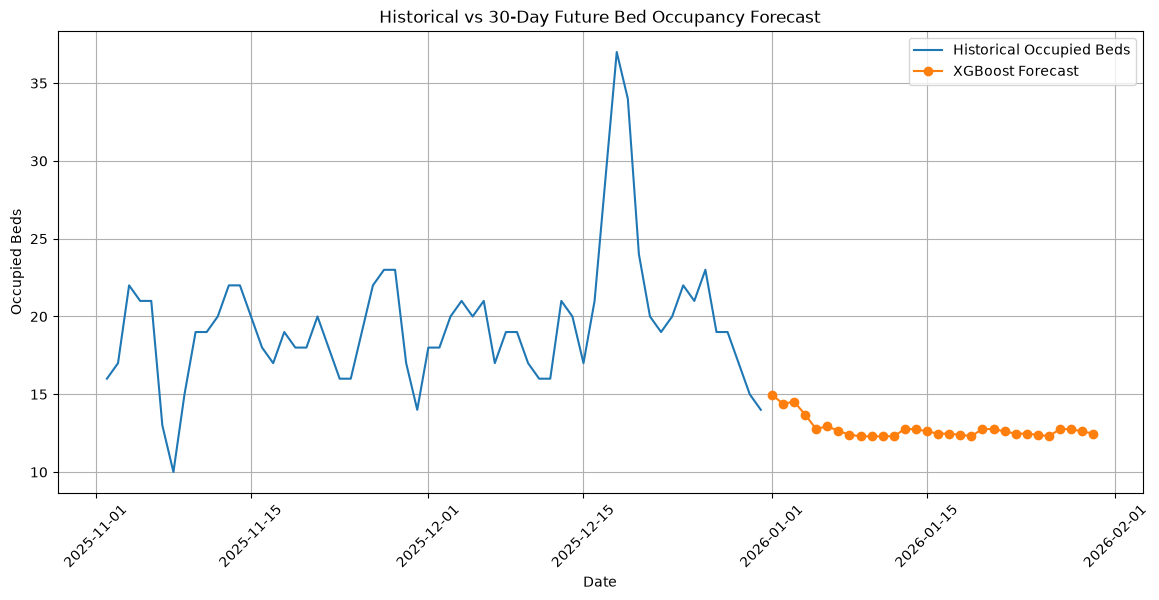

In [56]:
hospital_id = "HHN-BIR-01"
ward = "Cardiology Ward"


historical = model_df[
    (model_df["hospital_id"] == hospital_id) &
    (model_df["ward"] == ward)
].copy()


historical["date"] = pd.to_datetime(
    historical["date"]
)


future = xgb_future_forecast_df[
    (xgb_future_forecast_df["hospital_id"] == hospital_id) &
    (xgb_future_forecast_df["ward"] == ward)
]


plt.figure(figsize=(14,6))


# Historical occupancy
plt.plot(
    historical["date"].tail(60),
    historical["occupied_beds"].tail(60),
    label="Historical Occupied Beds"
)


# Future forecast
plt.plot(
    future["date"],
    future["predicted_occupied_beds"],
    marker="o",
    label="XGBoost Forecast"
)


plt.title(
    "Historical vs 30-Day Future Bed Occupancy Forecast"
)


plt.xlabel(
    "Date"
)


plt.ylabel(
    "Occupied Beds"
)


plt.legend()


plt.xticks(
    rotation=45
)


plt.grid(
    True
)


plt.show()

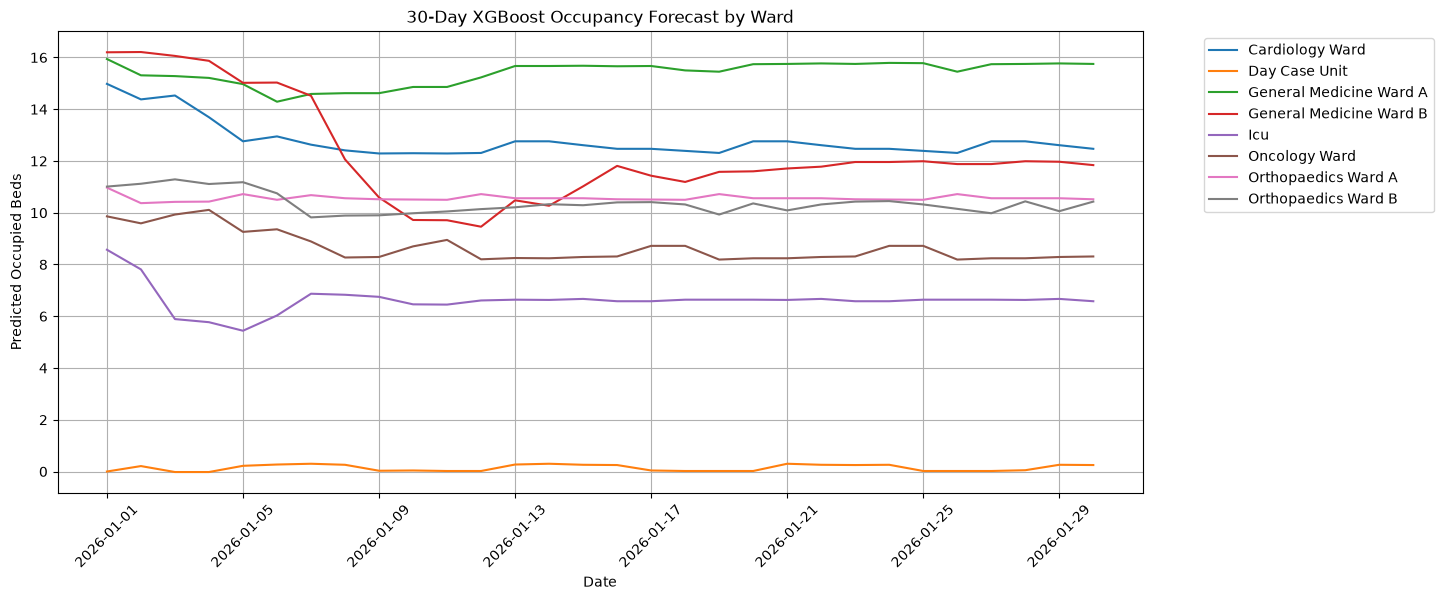

In [57]:
hospital_forecast = xgb_future_forecast_df[
    xgb_future_forecast_df["hospital_id"] == "HHN-BIR-01"
]


plt.figure(figsize=(14,6))


for ward in hospital_forecast["ward"].unique():

    ward_df = hospital_forecast[
        hospital_forecast["ward"] == ward
    ]

    plt.plot(
        ward_df["date"],
        ward_df["predicted_occupied_beds"],
        label=ward
    )


plt.title(
    "30-Day XGBoost Occupancy Forecast by Ward"
)


plt.xlabel(
    "Date"
)


plt.ylabel(
    "Predicted Occupied Beds"
)


plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)


plt.xticks(
    rotation=45
)


plt.grid(
    True
)


plt.show()

##### Combine future forecast with staff information

In [103]:
staffing_forecast_df.columns.tolist()

['hospital_id',
 'ward',
 'date',
 'predicted_occupied_beds',
 'planned_staff',
 'actual_staff',
 'safe_ratio_met',
 'staffing_ratio',
 'staffing_risk']

In [76]:
staffing_forecast_df = xgb_future_forecast_df.merge(

    model_df[
        [
            "hospital_id",
            "ward",
            "date",
            "staffed_beds",
            "planned_staff",
            "actual_staff",
            "staffing_ratio"
        ]
    ],

    on=[
        "hospital_id",
        "ward",
        "date"
    ],

    how="left"

)


##### Crate Bed demand pressure

In [64]:
staffing_forecast_df["bed_pressure"] = (

    staffing_forecast_df["predicted_occupied_beds"]

    /

    staffing_forecast_df["staffed_beds"]

)

##### Staffing gap

In [65]:
staffing_forecast_df["staff_gap"] = (

    staffing_forecast_df["planned_staff"]

    -

    staffing_forecast_df["actual_staff"]

)

##### Forecast Staffing Risk flag

In [68]:
staff = pd.read_csv("../data/raw/staffing_resource_clean.csv")

In [69]:
staff.columns.tolist()

['date',
 'hospital_id',
 'ward',
 'staff_role',
 'planned_staff',
 'actual_staff',
 'safe_ratio_met']

In [83]:
staff["date"] = pd.to_datetime(
    staff["date"]
)

xgb_future_forecast_df["date"] = pd.to_datetime(
    xgb_future_forecast_df["date"]
)

In [85]:
staff_daily = (

    staff
    .groupby(
        [
            "hospital_id",
            "ward",
            "date"
        ]
    )
    .agg(

        planned_staff=(
            "planned_staff",
            "sum"
        ),

        actual_staff=(
            "actual_staff",
            "sum"
        ),

        safe_ratio_met=(
            "safe_ratio_met",
            "first"
        )

    )

    .reset_index()

)

In [86]:
staffing_forecast_df = xgb_future_forecast_df.merge(

    staff_daily,

    on=[
        "hospital_id",
        "ward",
        "date"
    ],

    how="left"

)

In [90]:
latest_staff = (

    staff_daily
    .sort_values("date")
    .groupby(
        [
            "hospital_id",
            "ward"
        ]
    )
    .tail(1)

)

In [91]:
latest_staff.head()

,hospital_id,ward,date,planned_staff,actual_staff,safe_ratio_met
14619,HHN-LON-01,General Medicine Ward B,2025-12-31,14,14,Yes
27777,HHN-MAN-01,Oncology Ward,2025-12-31,10,10,Yes
11695,HHN-EDI-01,Orthopaedics Ward B,2025-12-31,4,4,Yes
10964,HHN-EDI-01,Orthopaedics Ward A,2025-12-31,4,4,Yes
10233,HHN-EDI-01,Oncology Ward,2025-12-31,6,6,Yes


In [92]:
staffing_forecast_df = xgb_future_forecast_df.merge(

    latest_staff[
        [
            "hospital_id",
            "ward",
            "planned_staff",
            "actual_staff",
            "safe_ratio_met"
        ]
    ],

    on=[
        "hospital_id",
        "ward"
    ],

    how="left"

)

In [93]:
staffing_forecast_df.head()

,hospital_id,ward,date,predicted_occupied_beds,planned_staff,actual_staff,safe_ratio_met
0,HHN-BIR-01,Cardiology Ward,2026-01-01,14.98,20.0,20.0,Yes
1,HHN-BIR-01,Cardiology Ward,2026-01-02,14.38,20.0,20.0,Yes
2,HHN-BIR-01,Cardiology Ward,2026-01-03,14.53,20.0,20.0,Yes
3,HHN-BIR-01,Cardiology Ward,2026-01-04,13.69,20.0,20.0,Yes
4,HHN-BIR-01,Cardiology Ward,2026-01-05,12.76,20.0,20.0,Yes


In [95]:
staffing_forecast_df["staffing_ratio"] = (

    staffing_forecast_df["actual_staff"]

    /

    staffing_forecast_df["planned_staff"]

)

In [97]:
staffing_forecast_df["staffing_risk"] = np.where(

    (
        staffing_forecast_df["staffing_ratio"] < 1
    )
    |
    (
        staffing_forecast_df["safe_ratio_met"] == "No"
    ),

    "High Risk",

    "Feasible"

)

Future bed occupancy forecasts were combined with the latest available staffing capacity profile. Since future staffing schedules were unavailable, the analysis assumed current staffing levels remain constant. This enabled identification of wards where forecast demand may exceed operational staffing capacity.

In [102]:
staffing_forecast_df.to_csv(
"../data/processed/staffing_risk_forecast.csv",
index=False
)

In [104]:
print(pd.read_csv("../data/processed/xgb_future_forecast.csv").columns.tolist())

['hospital_id', 'ward', 'date', 'predicted_occupied_beds']


In [105]:
sarimax_long = pd.read_csv(
    "../data/processed/sarimax_7_30_forecast.csv"
)

sarimax_long = sarimax_long.rename(
    columns={
        "forecast_occupied_beds": "predicted_occupied_beds"
    }
)

sarimax_long.to_csv(
    "../data/processed/sarimax_7_30_forecast.csv",
    index=False
)